<a href="https://colab.research.google.com/github/Amitabh-Phule/Reinforcement-Learning/blob/main/RL_Exp_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Title**
Value Iteration

## **Aim**
To implement Value Iteration for a Grid World problem and compare the results with Policy Iteration.

## **Theory**
Value Iteration is a Dynamic Programming method used in Reinforcement Learning to find the optimal value function and optimal policy.

Unlike Policy Iteration, which alternates between policy evaluation and policy improvement, Value Iteration directly updates the value of each state using the Bellman optimality equation.

The Bellman optimality equation is:

V(s) = max_a Σ P(s'|s,a) [R(s,a,s') + γV(s')]

where:

V(s) = Value of the current state
a = Possible action
P(s'|s,a) = Transition probability
R(s,a,s') = Reward
γ = Discount factor
V(s') = Value of the next state

For every state, Value Iteration calculates the value of all possible actions and selects the maximum value.

The process is repeated until the value function converges.

After convergence, the optimal policy is obtained by selecting the action with the highest expected value for each state.

In this experiment, Value Iteration is implemented on a 4 × 4 Grid World and its results are compared with Policy Iteration.

## **Algorithm**

1. Create a 4 × 4 Grid World environment.

2. Define the states and possible actions:
   Up, Down, Left, and Right.

3. Define the terminal states.

4. Initialize the value of every state to zero.

5. Set the discount factor γ and convergence threshold θ.

6. For every non-terminal state:
   a. Calculate the expected value for every possible action.
   b. Select the maximum action value.
   c. Update the value of the state.

7. Calculate the maximum change in the value function.

8. Repeat the value updates until the maximum change is less than θ.

9. Extract the optimal policy by selecting the action with the highest value for each state.

10. Display the optimal value function.

11. Display the optimal policy.

12. Compare the results with Policy Iteration.

## **Import Required Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Define Grid World**

In [2]:
## **Define Grid World**

grid_size = 4

states = [
    (r, c)
    for r in range(grid_size)
    for c in range(grid_size)
]

# Terminal states
terminal_states = [(0, 0), (3, 3)]

# Possible actions
actions = {
    "U": (-1, 0),
    "D": (1, 0),
    "L": (0, -1),
    "R": (0, 1)
}

print("Grid World:", grid_size, "x", grid_size)
print("Terminal States:", terminal_states)
print("Actions:", list(actions.keys()))

Grid World: 4 x 4
Terminal States: [(0, 0), (3, 3)]
Actions: ['U', 'D', 'L', 'R']


## **Define State Transition**

In [3]:
## **Define State Transition**

def get_next_state(state, action):

    if state in terminal_states:
        return state

    row, col = state
    dr, dc = actions[action]

    new_row = row + dr
    new_col = col + dc

    # Prevent movement outside the grid
    if new_row < 0 or new_row >= grid_size:
        return state

    if new_col < 0 or new_col >= grid_size:
        return state

    return (new_row, new_col)

## **Define Reward Function**

In [4]:
## **Define Reward Function**

def get_reward(state, next_state):

    if state in terminal_states:
        return 0

    # Every movement has a reward of -1
    return -1

## **Implement Value Iteration**

In [5]:
## **Implement Value Iteration**

gamma = 0.9
theta = 0.001

# Initialize value function
V = {
    state: 0.0
    for state in states
}

iteration = 0

while True:

    delta = 0

    new_V = V.copy()

    for state in states:

        # Skip terminal states
        if state in terminal_states:
            continue

        action_values = []

        # Calculate value for every action
        for action in actions:

            next_state = get_next_state(
                state,
                action
            )

            reward = get_reward(
                state,
                next_state
            )

            action_value = (
                reward +
                gamma * V[next_state]
            )

            action_values.append(action_value)

        # Bellman optimality update
        new_V[state] = max(action_values)

        delta = max(
            delta,
            abs(new_V[state] - V[state])
        )

    V = new_V
    iteration += 1

    if delta < theta:
        break

print("Value Iteration Completed.")
print("Number of iterations:", iteration)

Value Iteration Completed.
Number of iterations: 4


## **Extract Optimal Policy**

In [6]:
## **Extract Optimal Policy**

optimal_policy = {}

for state in states:

    if state in terminal_states:
        optimal_policy[state] = None
        continue

    action_values = {}

    for action in actions:

        next_state = get_next_state(
            state,
            action
        )

        reward = get_reward(
            state,
            next_state
        )

        action_values[action] = (
            reward +
            gamma * V[next_state]
        )

    # Select action with maximum value
    optimal_action = max(
        action_values,
        key=action_values.get
    )

    optimal_policy[state] = optimal_action

print("Optimal Policy Generated Successfully.")

Optimal Policy Generated Successfully.


## **Display Optimal Value Function**

In [7]:
## **Display Optimal Value Function**

print("========== OPTIMAL VALUE FUNCTION ==========\n")

for row in range(grid_size):

    for col in range(grid_size):

        state = (row, col)

        print(
            f"{V[state]:8.3f}",
            end=" "
        )

    print()

========== OPTIMAL VALUE FUNCTION ==========

   0.000   -1.000   -1.900   -2.710 
  -1.000   -1.900   -2.710   -1.900 
  -1.900   -2.710   -1.900   -1.000 
  -2.710   -1.900   -1.000    0.000 


## **Display Optimal Policy**

In [8]:
## **Display Optimal Policy**

print("========== OPTIMAL POLICY ==========\n")

for row in range(grid_size):

    for col in range(grid_size):

        state = (row, col)

        if state in terminal_states:
            print(" T ", end=" ")
        else:
            print(
                f" {optimal_policy[state]} ",
                end=" "
            )

    print()

print("\nLegend:")
print("U = Up")
print("D = Down")
print("L = Left")
print("R = Right")
print("T = Terminal")

========== OPTIMAL POLICY ==========

 T   L   L   D  
 U   U   U   D  
 U   U   D   D  
 U   R   R   T  

Legend:
U = Up
D = Down
L = Left
R = Right
T = Terminal


## **Visualize Optimal Policy**

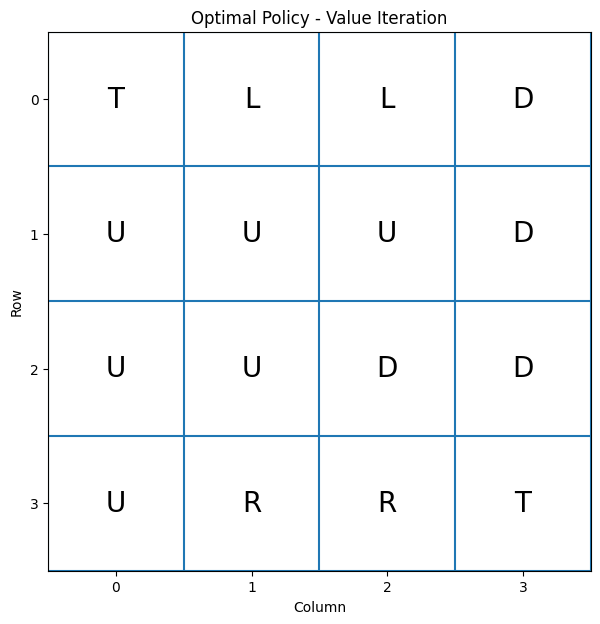

In [9]:
## **Visualize Optimal Policy**

plt.figure(figsize=(7, 7))

# Draw grid lines
for i in range(grid_size + 1):
    plt.axhline(i - 0.5)
    plt.axvline(i - 0.5)

# Display actions
for row in range(grid_size):

    for col in range(grid_size):

        state = (row, col)

        if state in terminal_states:
            text = "T"
        else:
            text = optimal_policy[state]

        plt.text(
            col,
            row,
            text,
            ha="center",
            va="center",
            fontsize=20
        )

plt.xlim(-0.5, grid_size - 0.5)
plt.ylim(grid_size - 0.5, -0.5)

plt.xticks(range(grid_size))
plt.yticks(range(grid_size))

plt.title("Optimal Policy - Value Iteration")
plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

## **Visualize Value Function**

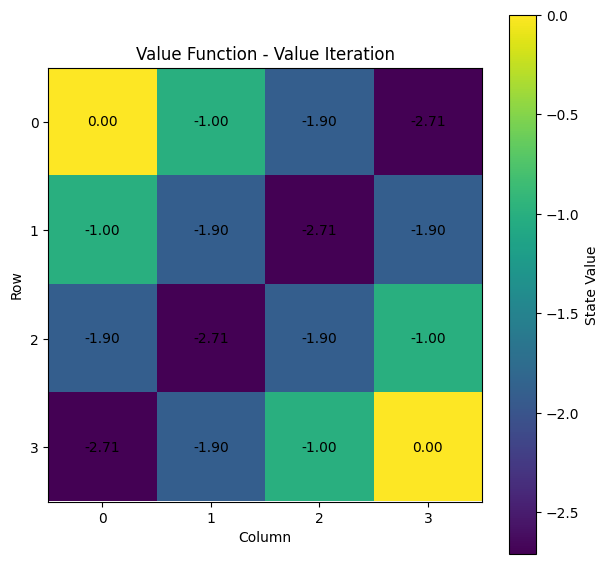

In [10]:
## **Visualize Value Function**

value_grid = np.zeros(
    (grid_size, grid_size)
)

for row in range(grid_size):

    for col in range(grid_size):

        value_grid[row, col] = V[
            (row, col)
        ]

plt.figure(figsize=(7, 7))

plt.imshow(value_grid)

plt.colorbar(label="State Value")

plt.xticks(range(grid_size))
plt.yticks(range(grid_size))

plt.title("Value Function - Value Iteration")

for row in range(grid_size):

    for col in range(grid_size):

        plt.text(
            col,
            row,
            f"{value_grid[row, col]:.2f}",
            ha="center",
            va="center"
        )

plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

## **Compare Value Iteration and Policy Iteration**

In [11]:
## **Compare Value Iteration and Policy Iteration**

print("========== COMPARISON ==========")

print("\nValue Iteration:")
print("Iterations:", iteration)

print("\nPolicy Iteration:")
print("Policy Iteration repeatedly performs:")
print("1. Policy Evaluation")
print("2. Policy Improvement")

print("\nComparison:")
print("Value Iteration directly applies the Bellman optimality equation.")
print("Policy Iteration alternates between evaluation and improvement.")
print("Both methods can obtain the optimal policy for the Grid World.")

========== COMPARISON ==========

Value Iteration:
Iterations: 4

Policy Iteration:
Policy Iteration repeatedly performs:
1. Policy Evaluation
2. Policy Improvement

Comparison:
Value Iteration directly applies the Bellman optimality equation.
Policy Iteration alternates between evaluation and improvement.
Both methods can obtain the optimal policy for the Grid World.


## **Observation**

1. A 4 × 4 Grid World was successfully created.

2. Value Iteration calculated the value of each state using the Bellman optimality equation.

3. The values were repeatedly updated until convergence.

4. The optimal action for each state was obtained from the final value function.

5. The resulting policy directs the agent toward the terminal state.

6. Value Iteration directly performs optimal value updates instead of separately performing complete policy evaluation and policy improvement.

7. The resulting optimal policy is comparable to the policy obtained using Policy Iteration.

## **Conclusion**

Value Iteration was successfully implemented for a Grid World environment.

The algorithm calculated the optimal value function by repeatedly applying the Bellman optimality equation and then extracted the optimal policy.

The results demonstrate that Value Iteration can be used to obtain an optimal policy in a known Grid World environment and can be compared with Policy Iteration.